<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    5000 non-null   str    
 1   pl_bmasse  4975 non-null   float64
 2   pl_rade    4961 non-null   float64
 3   pl_eqt     3881 non-null   float64
 4   st_teff    4819 non-null   float64
 5   sy_dist    4981 non-null   float64
dtypes: float64(5), str(1)
memory usage: 234.5 KB


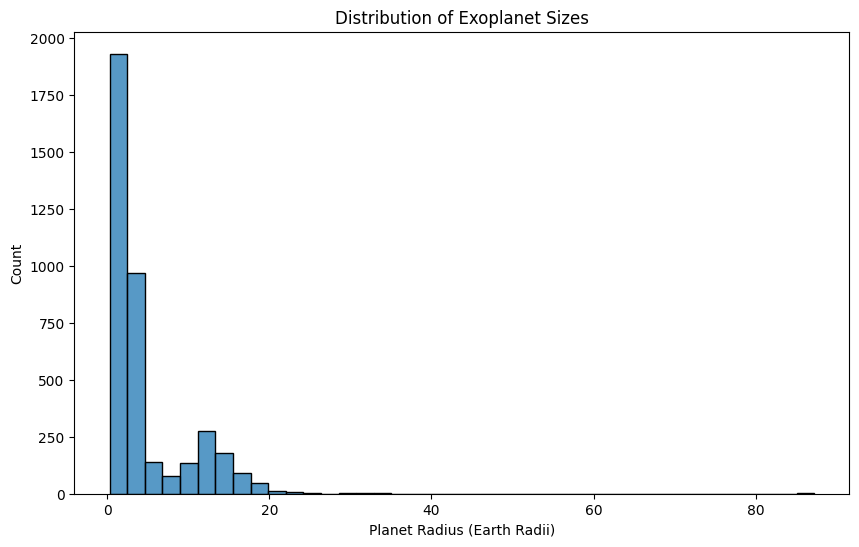

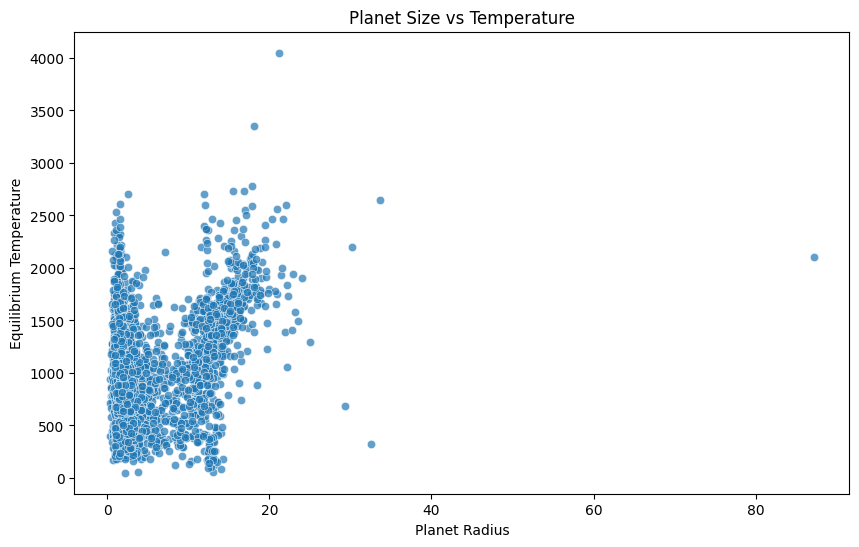

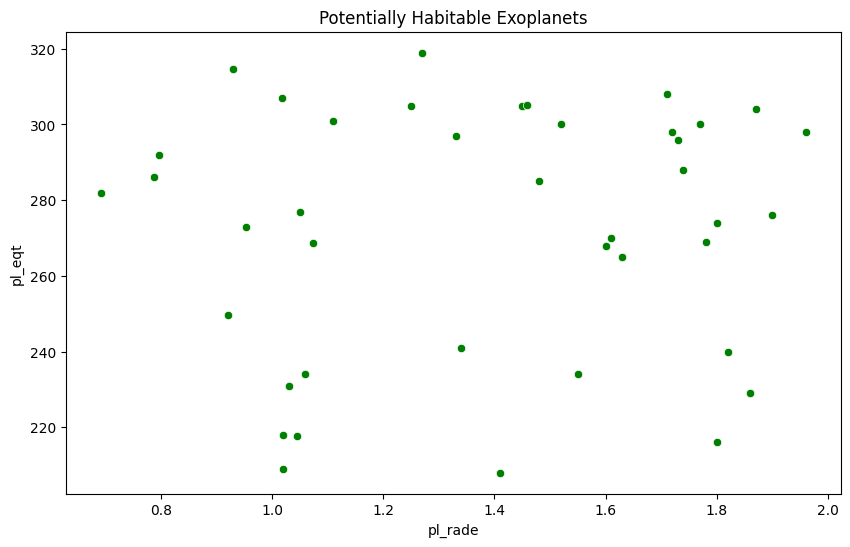

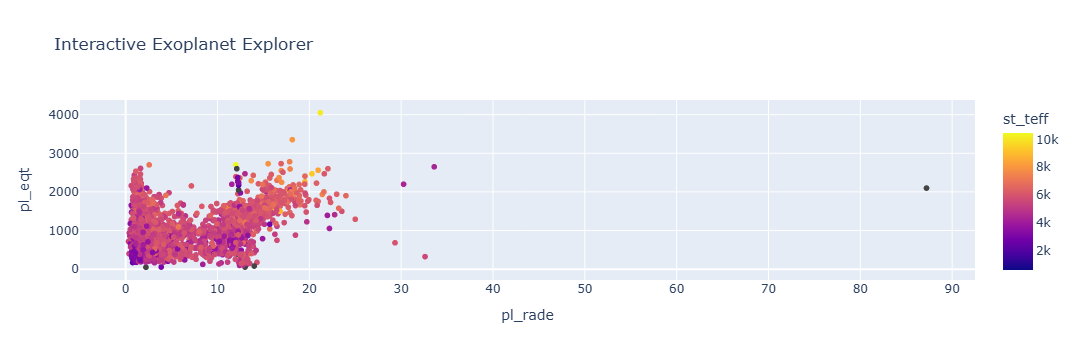

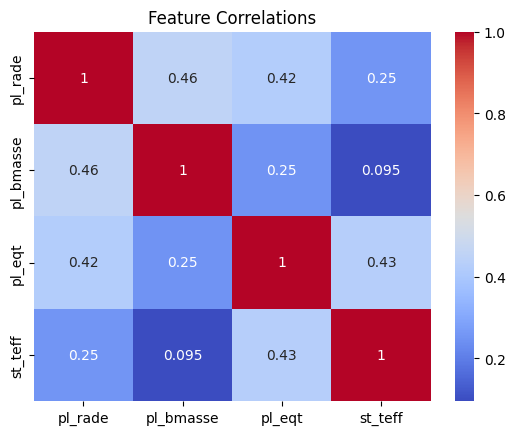

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+top+5000+pl_name,pl_bmasse,pl_rade,pl_eqt,st_teff,sy_dist+from+pscomppars&format=csv"
df = pd.read_csv(url)
df.head()
df.to_csv("../data/exoplanets.csv", index=False)
df.info()
df.describe()
df.isnull().sum()
df_clean = df.dropna(subset=["pl_rade", "pl_eqt"])
plt.figure(figsize=(10,6))

sns.histplot(df_clean["pl_rade"], bins=40)

plt.title("Distribution of Exoplanet Sizes")
plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Count")

plt.show()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="pl_rade",
    y="pl_eqt",
    alpha=0.7
)

plt.title("Planet Size vs Temperature")
plt.xlabel("Planet Radius")
plt.ylabel("Equilibrium Temperature")

plt.show()

habitable = df_clean[
    (df_clean["pl_eqt"] > 200) &
    (df_clean["pl_eqt"] < 320) &
    (df_clean["pl_rade"] < 2)
]

habitable.head()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=habitable,
    x="pl_rade",
    y="pl_eqt",
    color="green"
)

plt.title("Potentially Habitable Exoplanets")

plt.show()

import plotly.express as px

fig = px.scatter(
    df_clean,
    x="pl_rade",
    y="pl_eqt",
    hover_name="pl_name",
    color="st_teff",
    title="Interactive Exoplanet Explorer"
)

fig.show()

corr = df_clean[
    ["pl_rade", "pl_bmasse", "pl_eqt", "st_teff"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlations")

plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-59' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\aliso\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task finished name='Task-60' coro=<Kernel.shell_main() done, defined at C:\Users\aliso\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> exception=KeyError('89f35069-a46e-4f1e-8eac-4f111d685937')> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\aliso\AppData\Local\Programs\Python\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task exception was never retrieved
future: <Task finished name='Task-60' coro=<Kernel.shell_main() done, defined at C:\Users\aliso\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> exception=KeyError('89f35069-a46e-4f1e-8eac-4f111d685937')>
Traceback (most recent call last):
  File "C:\Users\aliso\AppData\Local\Programs\Py

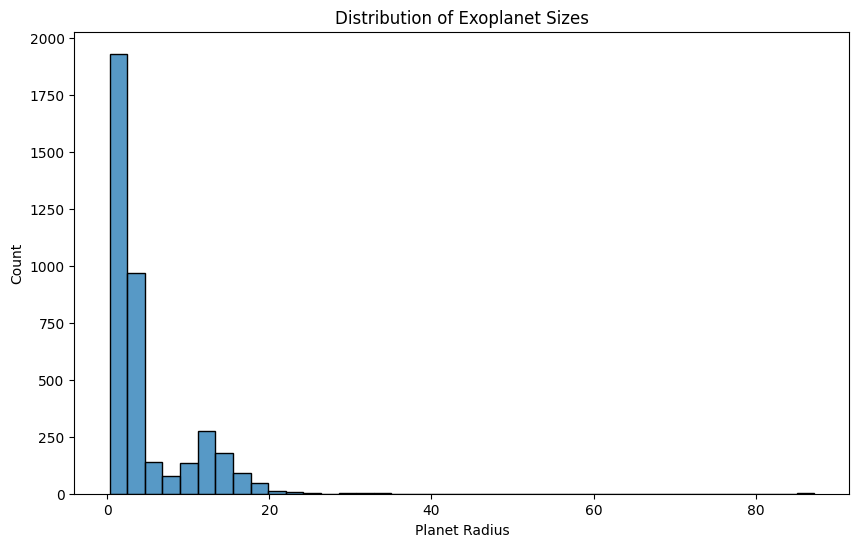

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df_clean["pl_rade"], bins=40)

plt.title("Distribution of Exoplanet Sizes")
plt.xlabel("Planet Radius")
plt.ylabel("Count")

plt.savefig("../images/radius_distribution.png")

plt.show()

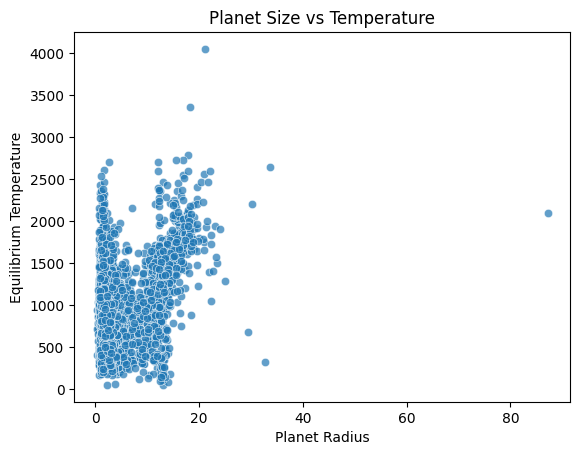

<Figure size 1000x600 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title("Planet Size vs Temperature")
plt.xlabel("Planet Radius")
plt.ylabel("Equilibrium Temperature")

sns.scatterplot(
    data=df_clean,
    x="pl_rade",
    y="pl_eqt",
    alpha=0.7
)

habitable = df_clean[
    (df_clean["pl_eqt"] > 200) &
    (df_clean["pl_eqt"] < 320) &
    (df_clean["pl_rade"] < 2)
]

habitable.head(
)

plt.figure(figsize=(10,6))

plt.savefig("../images/planet_temperature.png")

plt.show()